# Chapter 5 — Subspaces, Image, Kernel, Basis, Dimension

Numerical companion to `notes.md`. We'll:

1. Visualize subspaces of ℝ² and ℝ³ (lines and planes through the origin).
2. Compute the **image** (column space) and **kernel** (null space) of a matrix using RREF, and extract bases.
3. Test **linear independence** by stacking vectors and counting pivots.
4. Extract a **basis from a spanning set** (pivot-column rule).
5. Verify the **rank–nullity theorem** numerically on random matrices.
6. Convert a vector to **coordinates** in a non-standard basis and back.
7. Build a **change-of-basis matrix** and convert between two bases.
8. Application preview — treat polynomials as vectors (Ch 6 teaser).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## 1. What subspaces of ℝ³ look like

Subspaces of ℝ³ come in exactly four shapes: `{0}`, a **line through 0**, a **plane through 0**, and all of ℝ³ itself. Here are a 1D and a 2D example, drawn as finite chunks.

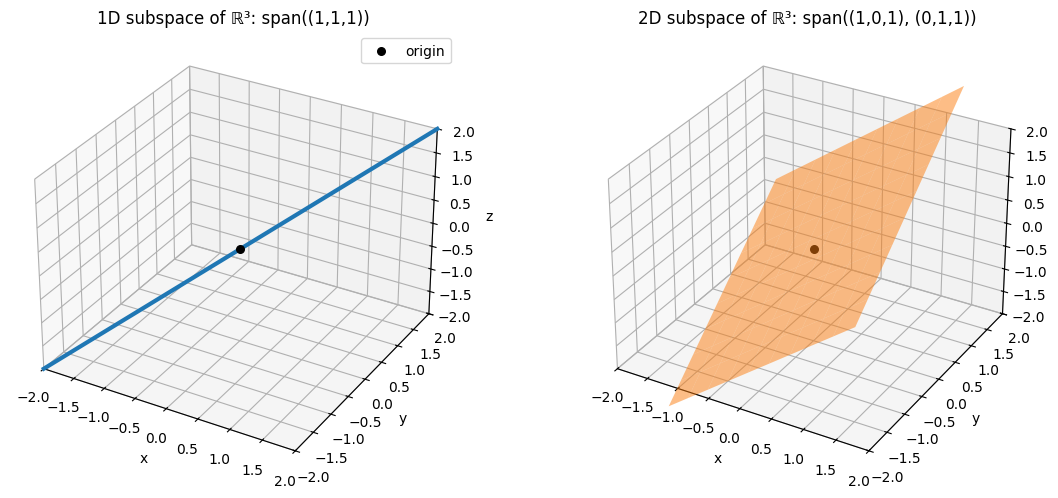

In [2]:
fig = plt.figure(figsize=(12, 5))

# Line through the origin: span((1, 1, 1))
ax1 = fig.add_subplot(121, projection='3d')
t = np.linspace(-2, 2, 40)
v = np.array([1, 1, 1])
line = np.outer(t, v)
ax1.plot(line[:, 0], line[:, 1], line[:, 2], lw=3, color='tab:blue')
ax1.scatter([0], [0], [0], color='k', s=30, label='origin')
ax1.set_title('1D subspace of ℝ³: span((1,1,1))')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_xlim(-2, 2); ax1.set_ylim(-2, 2); ax1.set_zlim(-2, 2)
ax1.legend()

# Plane through the origin: span((1, 0, 1), (0, 1, 1))
ax2 = fig.add_subplot(122, projection='3d')
s = np.linspace(-1.5, 1.5, 10)
t = np.linspace(-1.5, 1.5, 10)
S, T = np.meshgrid(s, t)
X = S * 1 + T * 0
Y = S * 0 + T * 1
Z = S * 1 + T * 1
ax2.plot_surface(X, Y, Z, alpha=0.5, color='tab:orange')
ax2.scatter([0], [0], [0], color='k', s=30)
ax2.set_title('2D subspace of ℝ³: span((1,0,1), (0,1,1))')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
ax2.set_xlim(-2, 2); ax2.set_ylim(-2, 2); ax2.set_zlim(-2, 2)

plt.tight_layout()
plt.show()

## 2. RREF from scratch

Everything in this chapter — image, kernel, rank, basis — reads off of RREF. Here's a small RREF routine we'll reuse.

In [3]:
def rref(M, tol=1e-10):
    A = np.array(M, dtype=float)
    m, n = A.shape
    row = 0
    pivot_cols = []
    for col in range(n):
        if row >= m:
            break
        # Find pivot in column `col`
        idx = np.argmax(np.abs(A[row:, col])) + row
        if abs(A[idx, col]) < tol:
            continue
        A[[row, idx]] = A[[idx, row]]
        A[row] = A[row] / A[row, col]
        for r in range(m):
            if r != row and abs(A[r, col]) > tol:
                A[r] = A[r] - A[r, col] * A[row]
        pivot_cols.append(col)
        row += 1
    # Clean tiny numerical noise
    A[np.abs(A) < tol] = 0
    return A, pivot_cols

A = np.array([[1, 2, 3],
              [2, 4, 6],
              [1, 1, 2]], dtype=float)
R, pivots = rref(A)
print('RREF(A) =')
print(R)
print('pivot columns:', pivots)

RREF(A) =
[[1. 0. 1.]
 [0. 1. 1.]
 [0. 0. 0.]]
pivot columns: [0, 1]


## 3. Image (column space) basis

Per §5.6.4, a basis of `im A` is formed by the **original columns of `A`** corresponding to pivot columns in RREF.

In [4]:
def image_basis(A):
    _, pivots = rref(A)
    return A[:, pivots], pivots

basis_im, pcols = image_basis(A)
print('Basis of im A (as columns):')
print(basis_im)
print(f'rank A = {len(pcols)}')

Basis of im A (as columns):
[[1. 2.]
 [2. 4.]
 [1. 1.]]
rank A = 2


## 4. Kernel (null space) basis

Set each free variable to 1 in turn (others to 0) and solve the pivot equations.

In [5]:
def kernel_basis(A, tol=1e-10):
    R, pivots = rref(A)
    m, n = R.shape
    free = [c for c in range(n) if c not in pivots]
    basis = []
    for f in free:
        v = np.zeros(n)
        v[f] = 1
        for i, p in enumerate(pivots):
            v[p] = -R[i, f]
        basis.append(v)
    return np.array(basis).T if basis else np.zeros((n, 0))

K = kernel_basis(A)
print('Basis of ker A (as columns):')
print(K)
print(f'nullity A = {K.shape[1]}')
print('Check A @ K ≈ 0:')
print(A @ K)

Basis of ker A (as columns):
[[-1.]
 [-1.]
 [ 1.]]
nullity A = 1
Check A @ K ≈ 0:
[[0.]
 [0.]
 [0.]]


## 5. Rank–nullity theorem on random matrices

`rank A + nullity A = n` (number of columns) for *every* matrix. Spot-check on a batch.

In [6]:
for trial in range(5):
    m = rng.integers(3, 7)
    n = rng.integers(3, 7)
    r_target = rng.integers(1, min(m, n) + 1)
    # Build a random matrix of rank r_target
    U = rng.normal(size=(m, r_target))
    V = rng.normal(size=(r_target, n))
    A_rand = U @ V
    _, pivots = rref(A_rand)
    rank = len(pivots)
    nullity = n - rank
    print(f'Matrix {trial+1}: shape {A_rand.shape}, rank {rank}, nullity {nullity}, '
          f'sum = {rank + nullity} (should be n = {n}) ✓' if rank + nullity == n else 'FAIL')

Matrix 1: shape (6, 5), rank 3, nullity 2, sum = 5 (should be n = 5) ✓
Matrix 2: shape (4, 4), rank 2, nullity 2, sum = 4 (should be n = 4) ✓
Matrix 3: shape (6, 6), rank 1, nullity 5, sum = 6 (should be n = 6) ✓
Matrix 4: shape (3, 6), rank 1, nullity 5, sum = 6 (should be n = 6) ✓
Matrix 5: shape (5, 6), rank 1, nullity 5, sum = 6 (should be n = 6) ✓


## 6. Linear independence test

Stack vectors as columns, count pivots. Independent ⇔ pivots in every column.

In [7]:
def independent(vectors):
    M = np.array(vectors).T  # columns = vectors
    _, pivots = rref(M)
    return len(pivots) == M.shape[1]

v1 = [1, 1, 2]
v2 = [2, 3, 5]
v3 = [1, 0, 1]
print(f'Independent? {independent([v1, v2, v3])}')

# Show the dependency
M = np.array([v1, v2, v3]).T
K = kernel_basis(M)
print(f'Kernel basis (the dependency coefficients):')
print(K)
print(f'  So {K[0,0]:.0f} v1 + {K[1,0]:.0f} v2 + {K[2,0]:.0f} v3 = 0')

Independent? False
Kernel basis (the dependency coefficients):
[[-3.]
 [ 1.]
 [ 1.]]
  So -3 v1 + 1 v2 + 1 v3 = 0


## 7. Extracting a basis from a redundant spanning set

`span(w₁, …, wₘ) = im M` where `M` has the `wᵢ`'s as columns. So `image_basis(M)` gives us a basis of the span, picked from the `wᵢ`'s.

In [8]:
W = np.array([[1, 2, 1, 3],
              [0, 1, 1, 1],
              [1, 2, 1, 3],
              [0, 1, 1, 1]], dtype=float)

B, picked = image_basis(W)
print(f'Picked columns: {picked}')
print('Basis of V = span(w1, w2, w3, w4):')
print(B)
print(f'dim V = {len(picked)}')

Picked columns: [0, 1]
Basis of V = span(w1, w2, w3, w4):
[[1. 2.]
 [0. 1.]
 [1. 2.]
 [0. 1.]]
dim V = 2


## 8. Visualizing the image and kernel of a rank-deficient 3×3

The motivating matrix from §5.0. Image is a 2D plane in ℝ³ (output side); kernel is a 1D line in ℝ³ (input side).

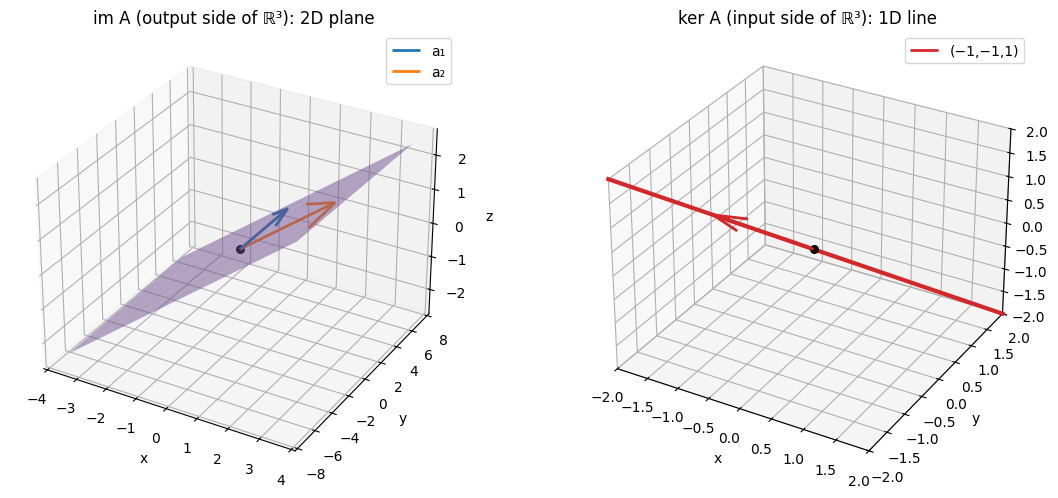

rank A = 2, nullity A = 1, sum = 3 ✓


In [9]:
A = np.array([[1, 2, 3],
              [2, 4, 6],
              [1, 1, 2]], dtype=float)

# Image: plane spanned by columns 1 and 2 (pivot columns)
b_im, _ = image_basis(A)
# Kernel: line spanned by (-1, -1, 1)
K = kernel_basis(A)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
s = np.linspace(-1.2, 1.2, 8)
t = np.linspace(-1.2, 1.2, 8)
S, T = np.meshgrid(s, t)
P = S[..., None] * b_im[:, 0] + T[..., None] * b_im[:, 1]
ax1.plot_surface(P[..., 0], P[..., 1], P[..., 2], alpha=0.5, color='tab:purple')
ax1.scatter([0], [0], [0], color='k', s=30)
for col, label, color in zip(b_im.T, ['a₁', 'a₂'], ['tab:blue', 'tab:orange']):
    ax1.quiver(0, 0, 0, col[0], col[1], col[2], color=color, lw=2, label=label)
ax1.set_title('im A (output side of ℝ³): 2D plane')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.legend()

ax2 = fig.add_subplot(122, projection='3d')
tt = np.linspace(-2, 2, 40)
kline = np.outer(tt, K[:, 0])
ax2.plot(kline[:, 0], kline[:, 1], kline[:, 2], lw=3, color='tab:red')
ax2.scatter([0], [0], [0], color='k', s=30)
ax2.quiver(0, 0, 0, K[0, 0], K[1, 0], K[2, 0], color='tab:red', lw=2, label='(−1,−1,1)')
ax2.set_title('ker A (input side of ℝ³): 1D line')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
ax2.set_xlim(-2, 2); ax2.set_ylim(-2, 2); ax2.set_zlim(-2, 2)
ax2.legend()

plt.tight_layout()
plt.show()

print(f'rank A = {A.shape[1] - K.shape[1]}, nullity A = {K.shape[1]}, sum = {A.shape[1]} ✓')

## 9. Coordinates in a non-standard basis

Given basis `𝓑 = (v₁, …, vₙ)` of ℝⁿ, the basis matrix `S = [v₁ | ⋯ | vₙ]` converts 𝓑-coordinates to standard coordinates: `x = S [x]_𝓑`. And `S⁻¹` goes the other way.

In [10]:
v1 = np.array([1, 0, 0])
v2 = np.array([1, 1, 0])
v3 = np.array([1, 1, 1])
S = np.column_stack([v1, v2, v3])
print('Basis matrix S =')
print(S)

x = np.array([4, 3, 2])
coords = np.linalg.solve(S, x)  # same as S^{-1} @ x
print(f'\n[x]_B = {coords}')
print(f'Rebuild x from coords: {S @ coords}  (should equal {x})')

Basis matrix S =
[[1 1 1]
 [0 1 1]
 [0 0 1]]

[x]_B = [1. 1. 2.]
Rebuild x from coords: [4. 3. 2.]  (should equal [4 3 2])


## 10. Change of basis

Given two bases `𝓑` and `𝓒` of ℝⁿ with basis matrices `S_𝓑` and `S_𝓒`, the change-of-basis matrix is `P = S_𝓒⁻¹ S_𝓑`. It converts 𝓑-coordinates to 𝓒-coordinates.

In [11]:
S_B = np.array([[1, 1],
                [2, 1]], dtype=float)   # basis B = ((1,2), (1,1))
S_C = np.array([[1, -1],
                [1,  1]], dtype=float)  # basis C = ((1,1), (-1,1))

P = np.linalg.solve(S_C, S_B)  # = S_C^{-1} @ S_B
print('Change-of-basis matrix P (B -> C):')
print(P)

x_B = np.array([3, 4])           # coordinates in B
x_C = P @ x_B                    # coordinates in C
x_std = S_B @ x_B                # rebuild in standard basis
print(f'\n[x]_B = {x_B}')
print(f'[x]_C = {x_C}')
print(f'x in standard coords (from B) = {x_std}')
print(f'x in standard coords (from C) = {S_C @ x_C}  (should match)')

Change-of-basis matrix P (B -> C):
[[1.5 1. ]
 [0.5 0. ]]

[x]_B = [3 4]
[x]_C = [8.5 1.5]
x in standard coords (from B) = [ 7. 10.]
x in standard coords (from C) = [ 7. 10.]  (should match)


## 11. Application — polynomial space as ℝⁿ (Ch 6 preview)

The space `P₂` of polynomials of degree ≤ 2 has basis `(1, x, x²)`. Each polynomial `p(x) = a₀ + a₁ x + a₂ x²` corresponds to the coefficient vector `(a₀, a₁, a₂)`.

Subproblem: **Find the polynomial of degree ≤ 2 passing through three data points `(x, y)`.** This is a *linear* problem in the coefficients — exactly an `Ax = b` in ℝ³.

Coefficient vector (a0, a1, a2) = [1. 0. 1.]


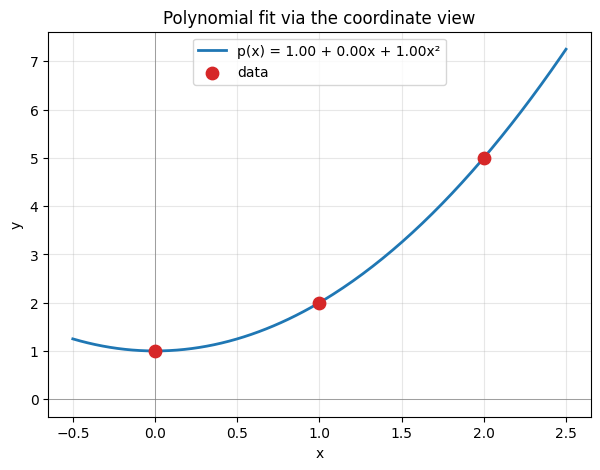

In [12]:
# Points to fit
xs = np.array([0.0, 1.0, 2.0])
ys = np.array([1.0, 2.0, 5.0])

# System: for each x, a0 + a1 x + a2 x^2 = y
# The coefficient matrix is the Vandermonde matrix.
A_poly = np.column_stack([np.ones_like(xs), xs, xs**2])
coefs = np.linalg.solve(A_poly, ys)
print(f'Coefficient vector (a0, a1, a2) = {coefs}')

xx = np.linspace(-0.5, 2.5, 200)
yy = coefs[0] + coefs[1] * xx + coefs[2] * xx**2

plt.figure(figsize=(7, 5))
plt.plot(xx, yy, '-', color='tab:blue', lw=2, label=f'p(x) = {coefs[0]:.2f} + {coefs[1]:.2f}x + {coefs[2]:.2f}x²')
plt.scatter(xs, ys, color='tab:red', s=80, zorder=5, label='data')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.title('Polynomial fit via the coordinate view')
plt.xlabel('x'); plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 12. Summary

- **Subspaces** are lines, planes, or higher flats through the origin. Detect via three axioms.
- **Image = column space** — span of the columns. Dimension = `rank`.
- **Kernel = null space** — solutions to `Ax = 0`. Dimension = `nullity`.
- **Rank–nullity:** `rank + nullity = n` (number of columns). Held on every random matrix above.
- A **basis** is a minimal spanning set — extract via RREF's pivot columns of the original matrix.
- **Coordinates** in a basis `𝓑` are unique; `S_𝓑` and `S_𝓑⁻¹` convert standard ↔ 𝓑.
- **Change of basis** between two bases: `P = S_𝓒⁻¹ S_𝓑`.
- **Preview:** polynomial fitting, function spaces — all still linear algebra, just not in ℝⁿ. That's Ch 6.
